# Model INSOUT

Model INSOUT is introduced in Chapter 10 (2nd ed.) / Chapter 7 (1st ed.) of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` "Monetary Economics: An Integrated Approach to Credit, Money, Income, Production and Wealth". It extends the LP family of models by introducing a full production sector with inventories, endogenous bank interest rates, wage-price dynamics, and a five-sector economy (Household, Firm, Government, Central Bank, Bank).

## Module Contents

As with all `MacroStat` models, INSOUT is divided into Variables, Parameters (fixed constants), Scenarios, and the Behavior (model initialization and steps). The module-level documentation can be seen in:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06INSOUT/variables.rst>
    Parameters <GL06INSOUT/parameters.rst>
    Equations <GL06INSOUT/equations.rst>
    Scenarios <GL06INSOUT/scenarios.rst>
```

The remainder of this page gives an introduction to the model, notes on how it is implemented in `MacroStat` and then shows some of the model dynamics across different scenarios.

## Model Overview

### Behavioral Equations

Model INSOUT introduces production with inventories, endogenous bank rates, and wage-price dynamics into the SFC framework. The key features are:

- **Firms** produce output, hold inventories financed by bank loans, and set prices as a markup over normal historic unit cost (including an indirect production tax)
- **Banks** set deposit and loan rates endogenously based on liquidity and profitability corridors
- **Households** allocate wealth across four non-cash assets (M1, M2, bills, bonds) using Tobin portfolio choice
- **Wage-price dynamics** with a Phillips-curve-style target real wage and partial adjustment

#### Firm Expectations and Pricing

1. Expected sales (adaptive expectations)
$$
s^e(t) = \beta \cdot s(t-1) + (1 - \beta) \cdot s^e(t-1)
$$

2. Target inventory-sales ratio
$$
\sigma^T(t) = \sigma_0 - \sigma_1 \cdot r_l(t)
$$

3. Target inventories
$$
inv^T(t) = \sigma^T(t) \cdot s^e(t)
$$

4. Expected inventories (partial adjustment)
$$
inv^e(t) = inv(t-1) - \gamma \cdot (inv(t-1) - inv^T(t))
$$

5. Normal historic unit cost
$$
NHUC(t) = (1 - \sigma^T) \cdot UC(t-1) + \sigma^T \cdot (1 + r_l(t-1)) \cdot UC(t-1)
$$

6. Price level (including indirect tax)
$$
p(t) = (1 + \tau) \cdot (1 + \phi) \cdot NHUC(t)
$$

7. Inflation rate
$$
\pi(t) = \frac{p(t) - p(t-1)}{p(t-1)}
$$

#### Firm Realized Outcomes

8. Real sales
$$
s(t) = c(t) + g(t)
$$

9. Nominal sales
$$
S(t) = s(t) \cdot p(t)
$$

10. Indirect production tax
$$
TX(t) = \frac{\tau}{1 + \tau} \cdot S(t)
$$

11. Real inventories
$$
inv(t) = inv(t-1) + y(t) - s(t)
$$

12. Nominal inventories (valued at unit cost)
$$
INV(t) = inv(t) \cdot UC(t)
$$

13. Loan demand
$$
L^d(t) = INV(t)
$$

14. Firm profits
$$
FP(t) = S(t) - TX(t) - WB(t) + (INV(t) - INV(t-1)) - r_l(t-1) \cdot L_s(t-1)
$$

15. Nominal output (sales at price + inventory change at cost)
$$
Y(t) = p(t) \cdot s(t) + UC(t) \cdot (inv(t) - inv(t-1))
$$

#### Household Behavioral

16. Real consumption
$$
c(t) = \alpha_0 + \alpha_1 \cdot yd_r^e(t) + \alpha_2 \cdot v(t-1)
$$

17. Expected real disposable income
$$
yd_r^e(t) = \varepsilon \cdot yd_r(t-1) + (1 - \varepsilon) \cdot yd_r^e(t-1)
$$

18. Nominal expected disposable income (with inflation adjustment)
$$
YD^e(t) = yd_r^e(t) \cdot p(t) + \pi(t) \cdot \frac{V(t-1)}{p(t)}
$$

19. Expected nominal wealth
$$
V^e(t) = V(t-1) + YD^e(t) - C(t)
$$

20. Cash demand
$$
Hh^d(t) = \lambda_c \cdot C(t)
$$

21. Expected non-cash wealth
$$
V^e_{nc}(t) = V^e(t) - Hh^d(t)
$$

#### Household Realized

22. Regular disposable income (no explicit tax; indirect tax netted in firm profits)
$$
YD_r(t) = WB(t) + FD(t) + r_m(t-1) \cdot M2_h(t-1) + r_b(t-1) \cdot B_h(t-1) + BL_h(t-1)
$$

23. Real regular disposable income (with inflation erosion)
$$
yd_r(t) = \frac{YD_r(t)}{p(t)} - \pi(t) \cdot \frac{V(t-1)}{p(t)}
$$

24. Capital gains
$$
CG(t) = (p_{bl}(t) - p_{bl}(t-1)) \cdot BL_h(t-1)
$$

25. Haig-Simons disposable income
$$
YD_{hs}(t) = YD_r(t) + CG(t)
$$

26. Nominal wealth
$$
V(t) = V(t-1) + YD_{hs}(t) - C(t)
$$

#### Portfolio Allocation

27. M2 demand, Bills demand, Bonds demand (Tobin portfolio allocation)
$$
M2^d(t) = V^e_{nc} \cdot (\lambda_{20} + \lambda_{22} \cdot r_m + \lambda_{23} \cdot r_b + \lambda_{24} \cdot ERr_{bl}) + \lambda_{25} \cdot YD^e
$$

$$
B^d(t) = V^e_{nc} \cdot (\lambda_{30} + \lambda_{32} \cdot r_m + \lambda_{33} \cdot r_b + \lambda_{34} \cdot ERr_{bl}) + \lambda_{35} \cdot YD^e
$$

$$
BL^d(t) = \frac{V^e_{nc} \cdot (\lambda_{40} + \lambda_{42} \cdot r_m + \lambda_{43} \cdot r_b + \lambda_{44} \cdot ERr_{bl}) + \lambda_{45} \cdot YD^e}{p_{bl}(t)}
$$

28. M1 demand (buffer-stock residual of actual non-cash wealth)
$$
M1^d(t) = V_{nc}(t) - M2^d(t) - B^d(t) - p_{bl}(t) \cdot BL^d(t)
$$

where $V_{nc} = V - Hh^d$ is actual (not expected) non-cash wealth.

29. M1/M2 switching regime: $z_1 = 1$ if $M1^d > 0$, else $z_2 = 1$ and M2 absorbs the residual.

#### Government

30. Government spending
$$
G(t) = g(t) \cdot p(t)
$$

31. Public sector borrowing requirement
$$
PSBR(t) = G(t) + r_b(t-1) \cdot B_s(t-1) + BL_s(t-1) - TX(t) - FCB(t)
$$

32. Bill supply (residual financing)
$$
B_s(t) = B_s(t-1) + PSBR(t) - (BL_s(t) - BL_s(t-1)) \cdot p_{bl}(t)
$$

#### Central Bank

33. Central bank profits
$$
FCB(t) = r_b(t-1) \cdot B_{cb}(t-1) + r_a(t-1) \cdot A_s(t-1)
$$

34. Advances supply
$$
A_s(t) = A^d(t)
$$

35. Central bank bill holdings (residual)
$$
B_{cb}(t) = B_s(t) - B_h(t) - B_b(t)
$$

#### Banks

36. Bank profits
$$
FBP(t) = r_l(t-1) \cdot L_s(t-1) + r_b(t-1) \cdot B_b(t-1) - r_m(t-1) \cdot M2_s(t-1) - r_a(t-1) \cdot A_s(t-1)
$$

37. Required reserves
$$
RR(t) = \rho_1 \cdot M1_s(t) + \rho_2 \cdot M2_s(t)
$$

38. Tentative bank bill holdings
$$
B_b^T(t) = M1_s + M2_s - L_s - Hb_s
$$

39. Advances demand (if $BLR^T < bot$)
$$
A^d(t) = \max(bot \cdot (M1_s + M2_s) - B_b^T, 0) \cdot z_3
$$

#### Endogenous Interest Rates

40. Deposit rate
$$
r_m(t) = r_m(t-1) + \zeta_m \cdot (z_4 - z_5) + \zeta_b \cdot (r_b(t) - r_b(t-1))
$$

41. Loan rate
$$
r_l(t) = r_l(t-1) + \zeta_l \cdot (z_6 - z_7) + (r_b(t) - r_b(t-1))
$$

where $z_4, z_5$ are liquidity corridor switches (using lagged $BLR^T$) and $z_6, z_7$ are profit corridor switches (using current-period $BPM$).

#### Wage-Price Dynamics

42. Target real wage
$$
\omega^T(t) = \exp(\Omega_0 + \Omega_1 \log(pr) + \Omega_2 \log(N(t)/N_{fe}))
$$

43. Nominal wage (partial adjustment to lagged target)
$$
W(t) = W(t-1) \cdot (1 + \Omega_3 \cdot (\omega^T(t-1) - W(t-1)/p(t-1)))
$$

### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model INSOUT
:file: GL06INSOUT/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model INSOUT
:file: GL06INSOUT/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Implementation in MacroStat

Transposing these equations to the `MacroStat` framework, we consider that there are:

1. **Twenty-eight parameters** (fixed constants): consumption propensities ($\alpha_0$, $\alpha_1$, $\alpha_2$), expectation weights ($\beta$, $\gamma$, $\varepsilon$), portfolio cash ratio ($\lambda_c$), markup ($\phi$), tax rate ($\tau$), production ($pr$, $N_{fe}$, $g$), inventory ($\sigma_0$, $\sigma_1$), reserves ($\rho_1$, $\rho_2$), bank corridors ($bot$, $top$, $bot_{pm}$, $top_{pm}$), rate adjustment speeds ($\zeta_b$, $\zeta_m$, $\zeta_l$), wage dynamics ($\Omega_0$--$\Omega_3$), and 20 portfolio $\lambda$ coefficients (see [Parameters](GL06INSOUT/parameters.rst))
2. **Three scenario variables**: $g(t)$, $r_b(t)$, and $r_{bl}(t)$ (see [Scenarios](GL06INSOUT/scenarios.rst))
3. The remaining tracked series are variables (see [Variables](GL06INSOUT/variables.rst))

## Model Dynamics

### Preparatory Steps

In [58]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from macrostat.models.GL06INSOUT import GL06INSOUT, ParametersGL06INSOUT, ScenariosGL06INSOUT

plt.style.use("../../macrostat.mplstyle")
plt.rcParams["axes.unicode_minus"] = False
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Running the Simulation

First, we run the model without any shocks to see the convergence to the steady state.

In [59]:
params = ParametersGL06INSOUT()
params.hyper["timesteps"] = 200
params.hyper["scenario_trigger"] = 100
model = GL06INSOUT(parameters=params)
model.simulate()
output = model.variables.to_pandas()

In [60]:
model.variables.check_health(tolerance=1e-3)

True

### Convergence to the Steady State

In the steady state with constant exogenous rates, inflation converges to zero, real variables stabilize, and all stock-flow norms reach constant values.

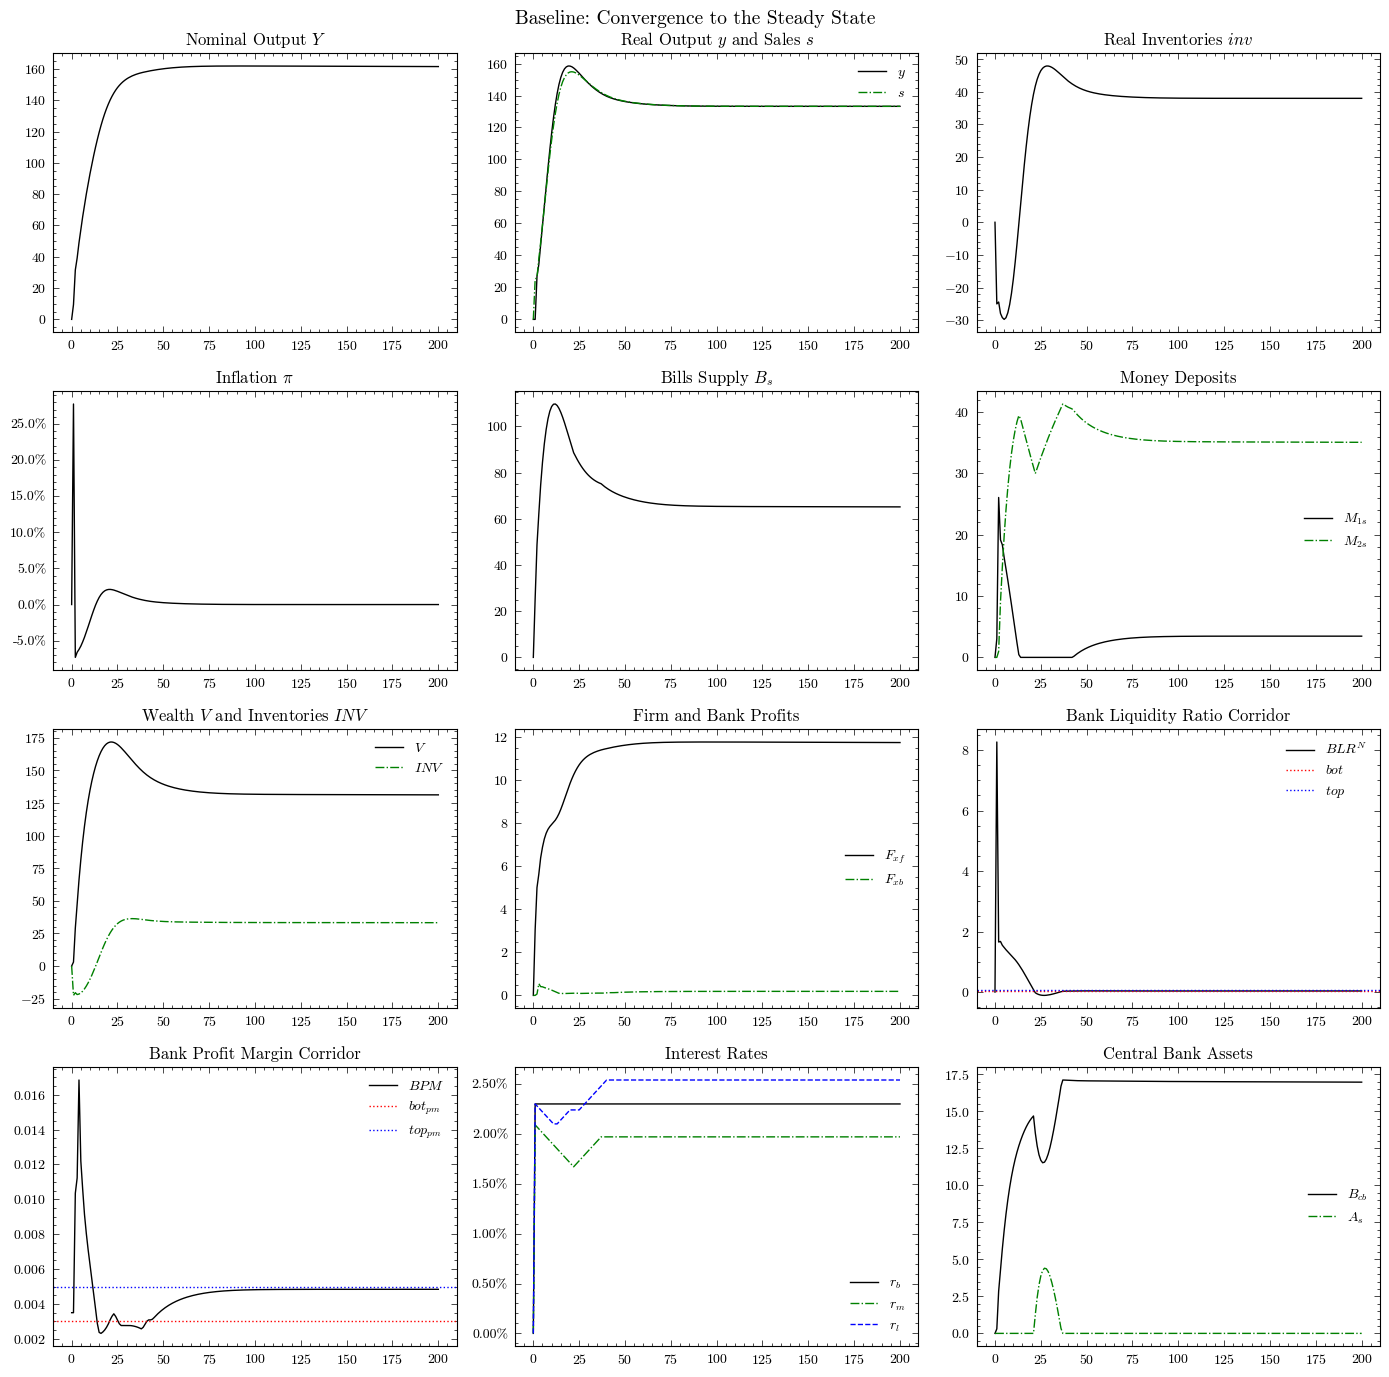

In [61]:
fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(14, 14))

axs[0, 0].plot(output.index, output['NominalOutput'], 'k')
axs[0, 0].set_title('Nominal Output $Y$')

axs[0, 1].plot(output.index, output['RealOutput'], 'k', label='$y$')
axs[0, 1].plot(output.index, output['RealSales'], 'g-.', label='$s$')
axs[0, 1].set_title('Real Output $y$ and Sales $s$')
axs[0, 1].legend(frameon=False)

axs[0, 2].plot(output.index, output['RealInventories'], 'k')
axs[0, 2].set_title('Real Inventories $inv$')

axs[1, 0].plot(output.index, output['InflationRate'], 'k')
axs[1, 0].set_title(r'Inflation $\pi$')
axs[1, 0].yaxis.set_major_formatter(PercentFormatter(1))

axs[1, 1].plot(output.index, output['BillsSupply'], 'k')
axs[1, 1].set_title('Bills Supply $B_s$')

axs[1, 2].plot(output.index, output['M1Supply'], 'k', label='$M_{1s}$')
axs[1, 2].plot(output.index, output['M2Supply'], 'g-.', label='$M_{2s}$')
axs[1, 2].set_title('Money Deposits')
axs[1, 2].legend(frameon=False)

axs[2, 0].plot(output.index, output['NominalWealth'], 'k', label='$V$')
axs[2, 0].plot(output.index, output['NominalInventories'], 'g-.', label='$INV$')
axs[2, 0].set_title('Wealth $V$ and Inventories $INV$')
axs[2, 0].legend(frameon=False)

axs[2, 1].plot(output.index, output['FirmProfits'], 'k', label='$F_{xf}$')
axs[2, 1].plot(output.index, output['BankProfits'], 'g-.', label='$F_{xb}$')
axs[2, 1].set_title('Firm and Bank Profits')
axs[2, 1].legend(frameon=False)

axs[2, 2].plot(output.index, output['BankLiquidityRatioTentative'], 'k', label='$BLR^N$')
axs[2, 2].axhline(y=params["BankLiquidityFloor"], color='r', ls=':', label='$bot$')
axs[2, 2].axhline(y=params["BankLiquidityCeiling"], color='b', ls=':', label='$top$')
axs[2, 2].set_title('Bank Liquidity Ratio Corridor')
axs[2, 2].legend(frameon=False)

axs[3, 0].plot(output.index, output['BankProfitMargin'], 'k', label='$BPM$')
axs[3, 0].axhline(y=params["BankProfitFloor"], color='r', ls=':', label='$bot_{pm}$')
axs[3, 0].axhline(y=params["BankProfitCeiling"], color='b', ls=':', label='$top_{pm}$')
axs[3, 0].set_title('Bank Profit Margin Corridor')
axs[3, 0].legend(frameon=False)

axs[3, 1].plot(output.index, output['BillRate'], 'k', label='$r_b$')
axs[3, 1].plot(output.index, output['DepositRate'], 'g-.', label='$r_m$')
axs[3, 1].plot(output.index, output['LoanRate'], 'b--', label='$r_l$')
axs[3, 1].set_title('Interest Rates')
axs[3, 1].yaxis.set_major_formatter(PercentFormatter(1))
axs[3, 1].legend(frameon=False)

axs[3, 2].plot(output.index, output['BillsCentralBank'], 'k', label='$B_{cb}$')
axs[3, 2].plot(output.index, output['AdvancesSupply'], 'g-.', label='$A_s$')
axs[3, 2].set_title('Central Bank Assets')
axs[3, 2].legend(frameon=False)

fig.suptitle('Baseline: Convergence to the Steady State', fontsize=14)
plt.tight_layout()
plt.show()

### Perturbation 1: Increase in Target Inventory Ratio (INSOUT1)

An increase in $\sigma_0$ from 0.3612 to 0.4. Firms desire larger inventory buffers, which raises inventory investment, loan demand, and bank lending.

In [62]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc1 = scenarios.get_scenario_index("Scenario.1: Higher target inventory ratio")
model1 = GL06INSOUT(parameters=params, scenarios=scenarios)
model1.simulate(scenario=sc1)
out1 = model1.variables.to_pandas()

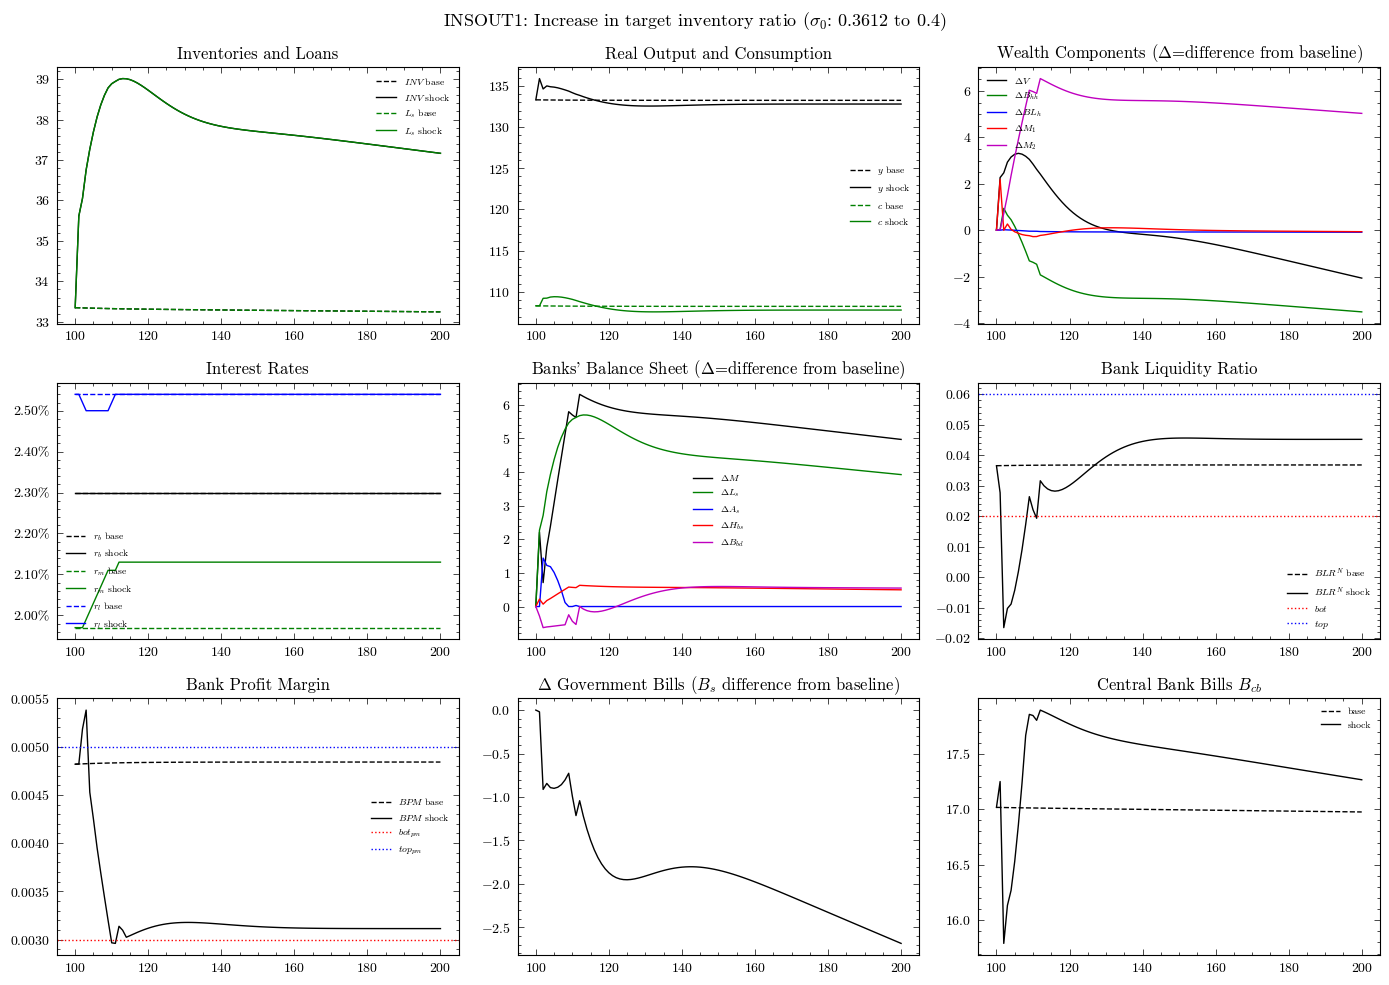

In [63]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(14, 10))

# Inventories and Loans
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'NominalInventories'], 'k--', label='$INV$ base')
axs[0, 0].plot(out1.loc[sl].index, out1.loc[sl, 'NominalInventories'], 'k-', label='$INV$ shock')
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'LoansSupply'], 'g--', label='$L_s$ base')
axs[0, 0].plot(out1.loc[sl].index, out1.loc[sl, 'LoansSupply'], 'g-', label='$L_s$ shock')
axs[0, 0].set_title('Inventories and Loans')
axs[0, 0].legend(frameon=False, fontsize=7)

# Real output and consumption
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'RealOutput'], 'k--', label='$y$ base')
axs[0, 1].plot(out1.loc[sl].index, out1.loc[sl, 'RealOutput'], 'k-', label='$y$ shock')
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'RealConsumption'], 'g--', label='$c$ base')
axs[0, 1].plot(out1.loc[sl].index, out1.loc[sl, 'RealConsumption'], 'g-', label='$c$ shock')
axs[0, 1].set_title('Real Output and Consumption')
axs[0, 1].legend(frameon=False, fontsize=7)

# Wealth components (delta from baseline)
dV = out1.loc[sl, 'NominalWealth'] - output.loc[sl, 'NominalWealth']
dBhh = out1.loc[sl, 'BillsHousehold'] - output.loc[sl, 'BillsHousehold']
dBLh = out1.loc[sl, 'BondsHousehold'] - output.loc[sl, 'BondsHousehold']
dM1 = out1.loc[sl, 'M1Supply'] - output.loc[sl, 'M1Supply']
dM2 = out1.loc[sl, 'M2Supply'] - output.loc[sl, 'M2Supply']
axs[0, 2].plot(dV.index, dV, 'k-', label=r'$\Delta V$')
axs[0, 2].plot(dBhh.index, dBhh, 'g-', label=r'$\Delta B_{hh}$')
axs[0, 2].plot(dBLh.index, dBLh, 'b-', label=r'$\Delta BL_h$')
axs[0, 2].plot(dM1.index, dM1, 'r-', label=r'$\Delta M_{1}$')
axs[0, 2].plot(dM2.index, dM2, 'm-', label=r'$\Delta M_{2}$')
axs[0, 2].set_title(r'Wealth Components ($\Delta$=difference from baseline)')
axs[0, 2].legend(frameon=False, fontsize=7)

# Interest rates
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'BillRate'], 'k--', label='$r_b$ base')
axs[1, 0].plot(out1.loc[sl].index, out1.loc[sl, 'BillRate'], 'k-', label='$r_b$ shock')
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'DepositRate'], 'g--', label='$r_m$ base')
axs[1, 0].plot(out1.loc[sl].index, out1.loc[sl, 'DepositRate'], 'g-', label='$r_m$ shock')
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'LoanRate'], 'b--', label='$r_l$ base')
axs[1, 0].plot(out1.loc[sl].index, out1.loc[sl, 'LoanRate'], 'b-', label='$r_l$ shock')
axs[1, 0].set_title('Interest Rates')
axs[1, 0].yaxis.set_major_formatter(PercentFormatter(1))
axs[1, 0].legend(frameon=False, fontsize=7)

# Banks' balance sheet (delta from baseline)
dM_tot = (out1.loc[sl, 'M1Supply'] + out1.loc[sl, 'M2Supply']) - (output.loc[sl, 'M1Supply'] + output.loc[sl, 'M2Supply'])
dLs = out1.loc[sl, 'LoansSupply'] - output.loc[sl, 'LoansSupply']
dAs = out1.loc[sl, 'AdvancesSupply'] - output.loc[sl, 'AdvancesSupply']
dHbs = out1.loc[sl, 'CashBanksSupply'] - output.loc[sl, 'CashBanksSupply']
dBbd = out1.loc[sl, 'BillsBank'] - output.loc[sl, 'BillsBank']
axs[1, 1].plot(dM_tot.index, dM_tot, 'k-', label=r'$\Delta M$')
axs[1, 1].plot(dLs.index, dLs, 'g-', label=r'$\Delta L_s$')
axs[1, 1].plot(dAs.index, dAs, 'b-', label=r'$\Delta A_s$')
axs[1, 1].plot(dHbs.index, dHbs, 'r-', label=r'$\Delta H_{bs}$')
axs[1, 1].plot(dBbd.index, dBbd, 'm-', label=r'$\Delta B_{bd}$')
axs[1, 1].set_title(r"Banks' Balance Sheet ($\Delta$=difference from baseline)")
axs[1, 1].legend(frameon=False, fontsize=7)

# Bank liquidity ratio corridor
axs[1, 2].plot(output.loc[sl].index, output.loc[sl, 'BankLiquidityRatioTentative'], 'k--', label='$BLR^N$ base')
axs[1, 2].plot(out1.loc[sl].index, out1.loc[sl, 'BankLiquidityRatioTentative'], 'k-', label='$BLR^N$ shock')
axs[1, 2].axhline(y=params["BankLiquidityFloor"], color='r', ls=':', label='$bot$')
axs[1, 2].axhline(y=params["BankLiquidityCeiling"], color='b', ls=':', label='$top$')
axs[1, 2].set_title('Bank Liquidity Ratio')
axs[1, 2].legend(frameon=False, fontsize=7)

# Bank profit margin corridor
axs[2, 0].plot(output.loc[sl].index, output.loc[sl, 'BankProfitMargin'], 'k--', label='$BPM$ base')
axs[2, 0].plot(out1.loc[sl].index, out1.loc[sl, 'BankProfitMargin'], 'k-', label='$BPM$ shock')
axs[2, 0].axhline(y=params["BankProfitFloor"], color='r', ls=':', label='$bot_{pm}$')
axs[2, 0].axhline(y=params["BankProfitCeiling"], color='b', ls=':', label='$top_{pm}$')
axs[2, 0].set_title('Bank Profit Margin')
axs[2, 0].legend(frameon=False, fontsize=7)

# Government bills change
dGb = out1.loc[sl, 'BillsSupply'] - output.loc[sl, 'BillsSupply']
axs[2, 1].plot(dGb.index, dGb, 'k-')
axs[2, 1].set_title(r'$\Delta$ Government Bills ($B_s$ difference from baseline)')

# Central bank bills
axs[2, 2].plot(output.loc[sl].index, output.loc[sl, 'BillsCentralBank'], 'k--', label='base')
axs[2, 2].plot(out1.loc[sl].index, out1.loc[sl, 'BillsCentralBank'], 'k-', label='shock')
axs[2, 2].set_title('Central Bank Bills $B_{cb}$')
axs[2, 2].legend(frameon=False, fontsize=7)

fig.suptitle(r'INSOUT1: Increase in target inventory ratio ($\sigma_0$: 0.3612 to 0.4)', fontsize=13)
plt.tight_layout()
plt.show()

### Perturbation 2: Increase in Government Expenditure (INSOUT2)

An increase in real government spending from $g = 25$ to $g = 30$. This is the standard Keynesian fiscal expansion.

In [64]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc2 = scenarios.get_scenario_index("Scenario.2: Higher government spending")
model2 = GL06INSOUT(parameters=params, scenarios=scenarios)
model2.simulate(scenario=sc2)
out2 = model2.variables.to_pandas()

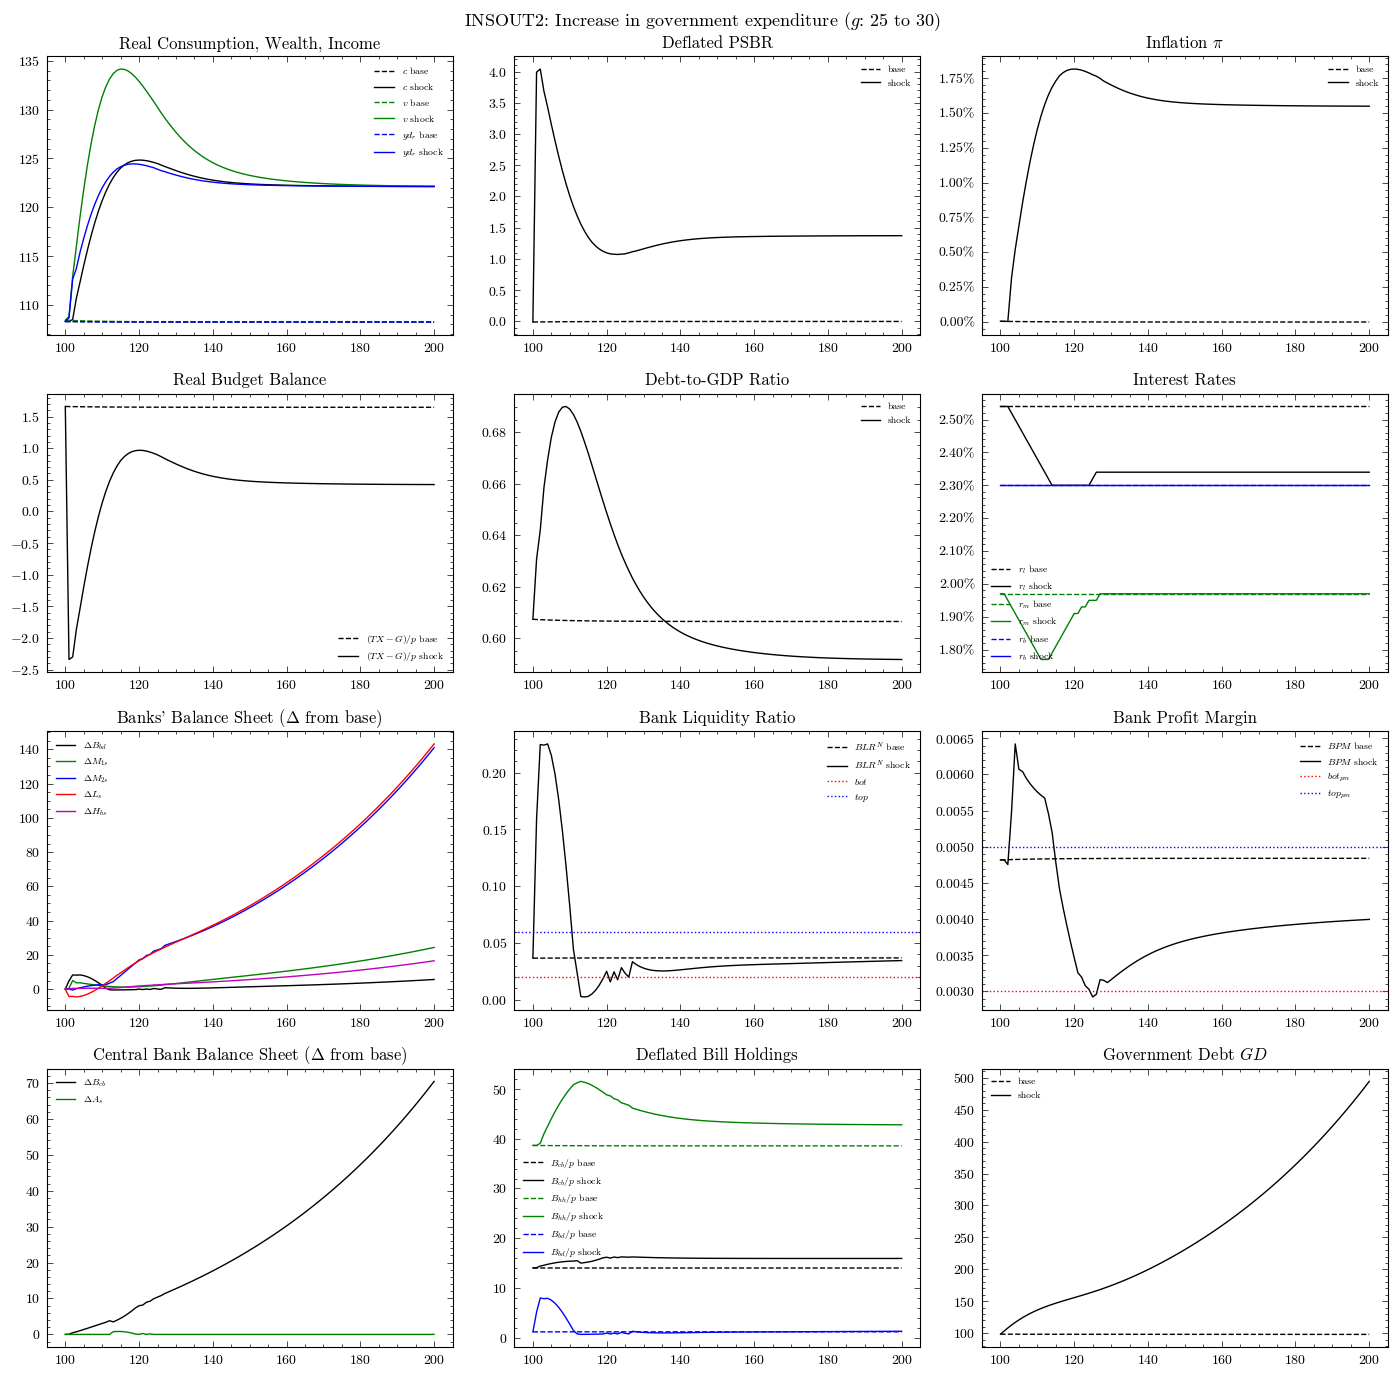

In [65]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(14, 14))

# Real consumption, wealth, and income
p_base = output.loc[sl, 'PriceLevel'].values
p_shock = out2.loc[sl, 'PriceLevel'].values
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'RealConsumption'], 'k--', label='$c$ base')
axs[0, 0].plot(out2.loc[sl].index, out2.loc[sl, 'RealConsumption'], 'k-', label='$c$ shock')
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'NominalWealth'].values / p_base, 'g--', label='$v$ base')
axs[0, 0].plot(out2.loc[sl].index, out2.loc[sl, 'NominalWealth'].values / p_shock, 'g-', label='$v$ shock')
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'RealRegularDisposableIncome'], 'b--', label='$yd_r$ base')
axs[0, 0].plot(out2.loc[sl].index, out2.loc[sl, 'RealRegularDisposableIncome'], 'b-', label='$yd_r$ shock')
axs[0, 0].set_title('Real Consumption, Wealth, Income')
axs[0, 0].legend(frameon=False, fontsize=7)

# Deflated PSBR
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'PublicSectorBorrowingRequirement'].values / p_base, 'k--', label='base')
axs[0, 1].plot(out2.loc[sl].index, out2.loc[sl, 'PublicSectorBorrowingRequirement'].values / p_shock, 'k-', label='shock')
axs[0, 1].set_title('Deflated PSBR')
axs[0, 1].legend(frameon=False, fontsize=7)

# Inflation
axs[0, 2].plot(output.loc[sl].index, output.loc[sl, 'InflationRate'], 'k--', label='base')
axs[0, 2].plot(out2.loc[sl].index, out2.loc[sl, 'InflationRate'], 'k-', label='shock')
axs[0, 2].set_title(r'Inflation $\pi$')
axs[0, 2].yaxis.set_major_formatter(PercentFormatter(1))
axs[0, 2].legend(frameon=False, fontsize=7)

# Real budget balance
budget_base = (output.loc[sl, 'Taxes'].values - output.loc[sl, 'GovernmentSpending'].values) / p_base
budget_shock = (out2.loc[sl, 'Taxes'].values - out2.loc[sl, 'GovernmentSpending'].values) / p_shock
axs[1, 0].plot(output.loc[sl].index, budget_base, 'k--', label='$(TX-G)/p$ base')
axs[1, 0].plot(out2.loc[sl].index, budget_shock, 'k-', label='$(TX-G)/p$ shock')
axs[1, 0].set_title('Real Budget Balance')
axs[1, 0].legend(frameon=False, fontsize=7)

# Debt-to-GDP ratio
byr_base = output.loc[sl, 'GovernmentDebt'].values / output.loc[sl, 'NominalOutput'].values
byr_shock = out2.loc[sl, 'GovernmentDebt'].values / out2.loc[sl, 'NominalOutput'].values
axs[1, 1].plot(output.loc[sl].index, byr_base, 'k--', label='base')
axs[1, 1].plot(out2.loc[sl].index, byr_shock, 'k-', label='shock')
axs[1, 1].set_title('Debt-to-GDP Ratio')
axs[1, 1].legend(frameon=False, fontsize=7)

# Interest rates
axs[1, 2].plot(output.loc[sl].index, output.loc[sl, 'LoanRate'], 'k--', label='$r_l$ base')
axs[1, 2].plot(out2.loc[sl].index, out2.loc[sl, 'LoanRate'], 'k-', label='$r_l$ shock')
axs[1, 2].plot(output.loc[sl].index, output.loc[sl, 'DepositRate'], 'g--', label='$r_m$ base')
axs[1, 2].plot(out2.loc[sl].index, out2.loc[sl, 'DepositRate'], 'g-', label='$r_m$ shock')
axs[1, 2].plot(output.loc[sl].index, output.loc[sl, 'BillRate'], 'b--', label='$r_b$ base')
axs[1, 2].plot(out2.loc[sl].index, out2.loc[sl, 'BillRate'], 'b-', label='$r_b$ shock')
axs[1, 2].set_title('Interest Rates')
axs[1, 2].yaxis.set_major_formatter(PercentFormatter(1))
axs[1, 2].legend(frameon=False, fontsize=7)

# Banks' balance sheet (delta from baseline)
dBbd = out2.loc[sl, 'BillsBank'] - output.loc[sl, 'BillsBank']
dM1s = out2.loc[sl, 'M1Supply'] - output.loc[sl, 'M1Supply']
dM2s = out2.loc[sl, 'M2Supply'] - output.loc[sl, 'M2Supply']
dLs = out2.loc[sl, 'LoansSupply'] - output.loc[sl, 'LoansSupply']
dHbs = out2.loc[sl, 'CashBanksSupply'] - output.loc[sl, 'CashBanksSupply']
axs[2, 0].plot(dBbd.index, dBbd, 'k-', label=r'$\Delta B_{bd}$')
axs[2, 0].plot(dM1s.index, dM1s, 'g-', label=r'$\Delta M_{1s}$')
axs[2, 0].plot(dM2s.index, dM2s, 'b-', label=r'$\Delta M_{2s}$')
axs[2, 0].plot(dLs.index, dLs, 'r-', label=r'$\Delta L_s$')
axs[2, 0].plot(dHbs.index, dHbs, 'm-', label=r'$\Delta H_{bs}$')
axs[2, 0].set_title(r"Banks' Balance Sheet ($\Delta$ from base)")
axs[2, 0].legend(frameon=False, fontsize=7)

# Bank liquidity ratio corridor
axs[2, 1].plot(output.loc[sl].index, output.loc[sl, 'BankLiquidityRatioTentative'], 'k--', label='$BLR^N$ base')
axs[2, 1].plot(out2.loc[sl].index, out2.loc[sl, 'BankLiquidityRatioTentative'], 'k-', label='$BLR^N$ shock')
axs[2, 1].axhline(y=params["BankLiquidityFloor"], color='r', ls=':', label='$bot$')
axs[2, 1].axhline(y=params["BankLiquidityCeiling"], color='b', ls=':', label='$top$')
axs[2, 1].set_title('Bank Liquidity Ratio')
axs[2, 1].legend(frameon=False, fontsize=7)

# Bank profit margin corridor
axs[2, 2].plot(output.loc[sl].index, output.loc[sl, 'BankProfitMargin'], 'k--', label='$BPM$ base')
axs[2, 2].plot(out2.loc[sl].index, out2.loc[sl, 'BankProfitMargin'], 'k-', label='$BPM$ shock')
axs[2, 2].axhline(y=params["BankProfitFloor"], color='r', ls=':', label='$bot_{pm}$')
axs[2, 2].axhline(y=params["BankProfitCeiling"], color='b', ls=':', label='$top_{pm}$')
axs[2, 2].set_title('Bank Profit Margin')
axs[2, 2].legend(frameon=False, fontsize=7)

# Central bank balance sheet (delta)
dAs = out2.loc[sl, 'AdvancesSupply'] - output.loc[sl, 'AdvancesSupply']
dBcb = out2.loc[sl, 'BillsCentralBank'] - output.loc[sl, 'BillsCentralBank']
axs[3, 0].plot(dBcb.index, dBcb, 'k-', label=r'$\Delta B_{cb}$')
axs[3, 0].plot(dAs.index, dAs, 'g-', label=r'$\Delta A_s$')
axs[3, 0].set_title(r'Central Bank Balance Sheet ($\Delta$ from base)')
axs[3, 0].legend(frameon=False, fontsize=7)

# Deflated bill holdings
axs[3, 1].plot(output.loc[sl].index, output.loc[sl, 'BillsCentralBank'].values / p_base, 'k--', label='$B_{cb}/p$ base')
axs[3, 1].plot(out2.loc[sl].index, out2.loc[sl, 'BillsCentralBank'].values / p_shock, 'k-', label='$B_{cb}/p$ shock')
axs[3, 1].plot(output.loc[sl].index, output.loc[sl, 'BillsHousehold'].values / p_base, 'g--', label='$B_{hh}/p$ base')
axs[3, 1].plot(out2.loc[sl].index, out2.loc[sl, 'BillsHousehold'].values / p_shock, 'g-', label='$B_{hh}/p$ shock')
axs[3, 1].plot(output.loc[sl].index, output.loc[sl, 'BillsBank'].values / p_base, 'b--', label='$B_{bd}/p$ base')
axs[3, 1].plot(out2.loc[sl].index, out2.loc[sl, 'BillsBank'].values / p_shock, 'b-', label='$B_{bd}/p$ shock')
axs[3, 1].set_title('Deflated Bill Holdings')
axs[3, 1].legend(frameon=False, fontsize=7)

# Government debt
axs[3, 2].plot(output.loc[sl].index, output.loc[sl, 'GovernmentDebt'], 'k--', label='base')
axs[3, 2].plot(out2.loc[sl].index, out2.loc[sl, 'GovernmentDebt'], 'k-', label='shock')
axs[3, 2].set_title('Government Debt $GD$')
axs[3, 2].legend(frameon=False, fontsize=7)

fig.suptitle('INSOUT2: Increase in government expenditure ($g$: 25 to 30)', fontsize=13)
plt.tight_layout()
plt.show()

### Perturbation 3: Increase in Compulsory Reserve Ratios (INSOUT3)

An increase in reserve ratios from $\rho_1 = \rho_2 = 0.1$ to $\rho_1 = \rho_2 = 0.2$.

In [66]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc3 = scenarios.get_scenario_index("Scenario.3: Higher reserve requirements")
model3 = GL06INSOUT(parameters=params, scenarios=scenarios)
model3.simulate(scenario=sc3)
out3 = model3.variables.to_pandas()

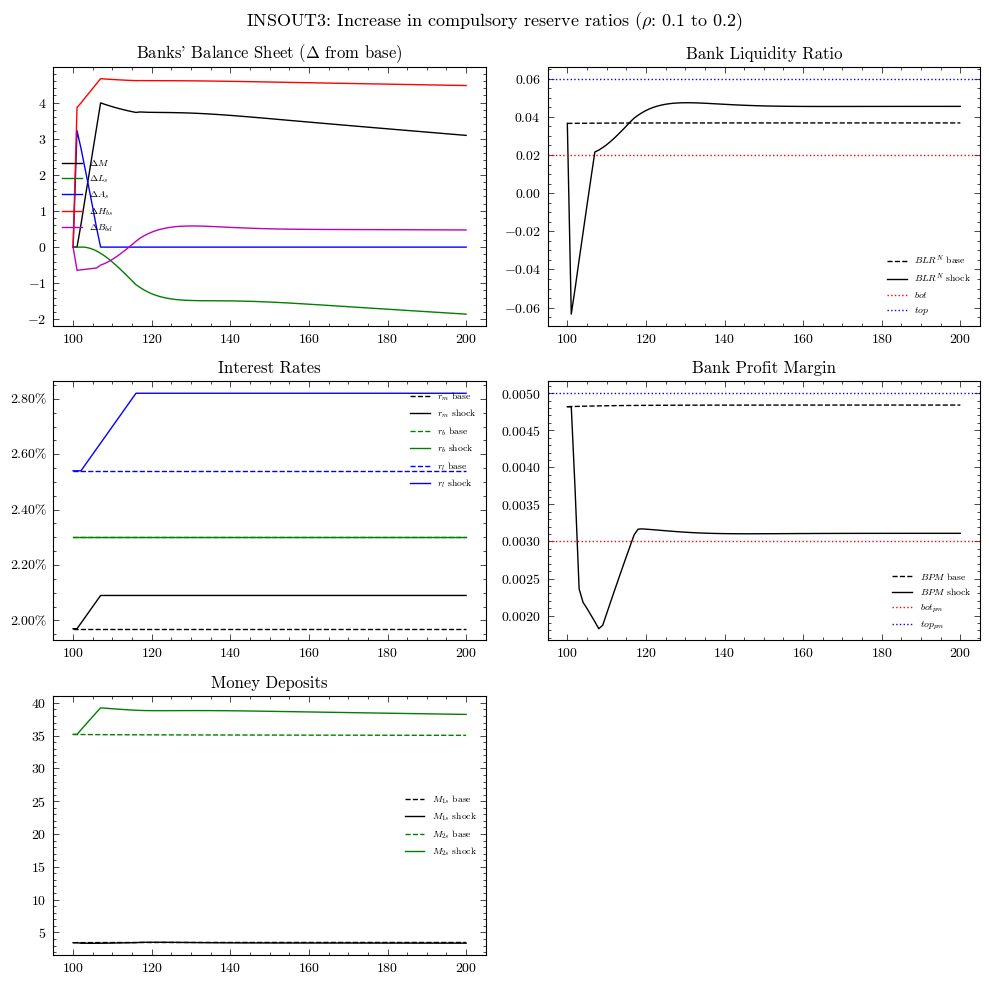

In [67]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 10))

# Banks' balance sheet (delta from baseline)
dM = (out3.loc[sl, 'M1Supply'] + out3.loc[sl, 'M2Supply']) - (output.loc[sl, 'M1Supply'] + output.loc[sl, 'M2Supply'])
dLs = out3.loc[sl, 'LoansSupply'] - output.loc[sl, 'LoansSupply']
dAs = out3.loc[sl, 'AdvancesSupply'] - output.loc[sl, 'AdvancesSupply']
dHbs = out3.loc[sl, 'CashBanksSupply'] - output.loc[sl, 'CashBanksSupply']
dBbd = out3.loc[sl, 'BillsBank'] - output.loc[sl, 'BillsBank']
axs[0, 0].plot(dM.index, dM, 'k-', label=r'$\Delta M$')
axs[0, 0].plot(dLs.index, dLs, 'g-', label=r'$\Delta L_s$')
axs[0, 0].plot(dAs.index, dAs, 'b-', label=r'$\Delta A_s$')
axs[0, 0].plot(dHbs.index, dHbs, 'r-', label=r'$\Delta H_{bs}$')
axs[0, 0].plot(dBbd.index, dBbd, 'm-', label=r'$\Delta B_{bd}$')
axs[0, 0].set_title(r"Banks' Balance Sheet ($\Delta$ from base)")
axs[0, 0].legend(frameon=False, fontsize=7)

# Bank liquidity ratio corridor
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'BankLiquidityRatioTentative'], 'k--', label='$BLR^N$ base')
axs[0, 1].plot(out3.loc[sl].index, out3.loc[sl, 'BankLiquidityRatioTentative'], 'k-', label='$BLR^N$ shock')
axs[0, 1].axhline(y=params["BankLiquidityFloor"], color='r', ls=':', label='$bot$')
axs[0, 1].axhline(y=params["BankLiquidityCeiling"], color='b', ls=':', label='$top$')
axs[0, 1].set_title('Bank Liquidity Ratio')
axs[0, 1].legend(frameon=False, fontsize=7)

# Interest rates
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'DepositRate'], 'k--', label='$r_m$ base')
axs[1, 0].plot(out3.loc[sl].index, out3.loc[sl, 'DepositRate'], 'k-', label='$r_m$ shock')
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'BillRate'], 'g--', label='$r_b$ base')
axs[1, 0].plot(out3.loc[sl].index, out3.loc[sl, 'BillRate'], 'g-', label='$r_b$ shock')
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'LoanRate'], 'b--', label='$r_l$ base')
axs[1, 0].plot(out3.loc[sl].index, out3.loc[sl, 'LoanRate'], 'b-', label='$r_l$ shock')
axs[1, 0].set_title('Interest Rates')
axs[1, 0].yaxis.set_major_formatter(PercentFormatter(1))
axs[1, 0].legend(frameon=False, fontsize=7)

# Bank profit margin corridor
axs[1, 1].plot(output.loc[sl].index, output.loc[sl, 'BankProfitMargin'], 'k--', label='$BPM$ base')
axs[1, 1].plot(out3.loc[sl].index, out3.loc[sl, 'BankProfitMargin'], 'k-', label='$BPM$ shock')
axs[1, 1].axhline(y=params["BankProfitFloor"], color='r', ls=':', label='$bot_{pm}$')
axs[1, 1].axhline(y=params["BankProfitCeiling"], color='b', ls=':', label='$top_{pm}$')
axs[1, 1].set_title('Bank Profit Margin')
axs[1, 1].legend(frameon=False, fontsize=7)

# Money deposits
axs[2, 0].plot(output.loc[sl].index, output.loc[sl, 'M1Supply'], 'k--', label='$M_{1s}$ base')
axs[2, 0].plot(out3.loc[sl].index, out3.loc[sl, 'M1Supply'], 'k-', label='$M_{1s}$ shock')
axs[2, 0].plot(output.loc[sl].index, output.loc[sl, 'M2Supply'], 'g--', label='$M_{2s}$ base')
axs[2, 0].plot(out3.loc[sl].index, out3.loc[sl, 'M2Supply'], 'g-', label='$M_{2s}$ shock')
axs[2, 0].set_title('Money Deposits')
axs[2, 0].legend(frameon=False, fontsize=7)

axs[2, 1].axis('off')

fig.suptitle(r'INSOUT3: Increase in compulsory reserve ratios ($\rho$: 0.1 to 0.2)', fontsize=13)
plt.tight_layout()
plt.show()

### Perturbation 4: Increase in Acceptable Bank Liquidity Ratio (INSOUT4)

An increase in the liquidity corridor from $bot = 0.02, top = 0.06$ to $bot = 0.20, top = 0.24$.

In [68]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc4 = scenarios.get_scenario_index("Scenario.4: Wider liquidity corridor")
model4 = GL06INSOUT(parameters=params, scenarios=scenarios)
model4.simulate(scenario=sc4)
out4 = model4.variables.to_pandas()

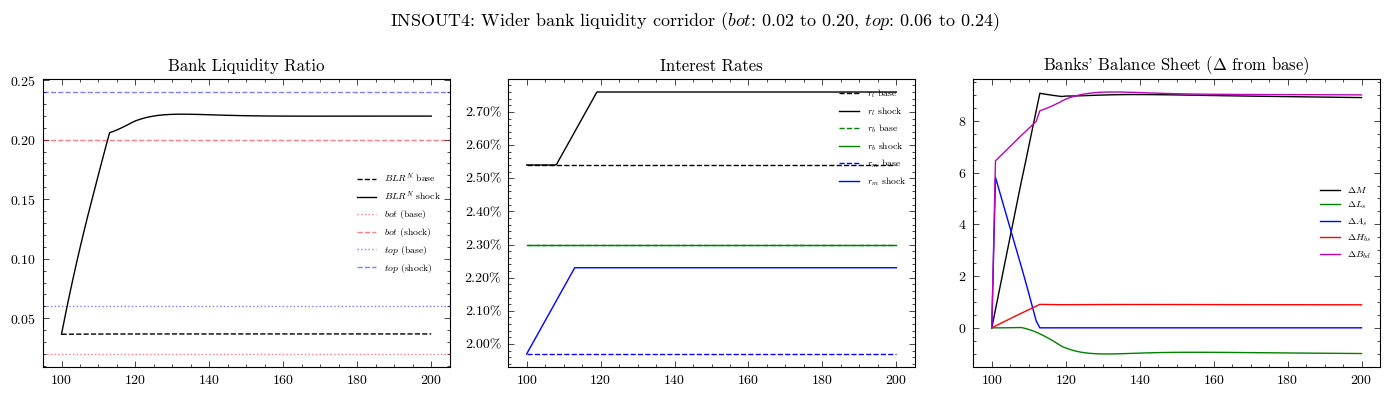

In [69]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(14, 4))

# Bank liquidity ratio corridor
axs[0].plot(output.loc[sl].index, output.loc[sl, 'BankLiquidityRatioTentative'], 'k--', label='$BLR^N$ base')
axs[0].plot(out4.loc[sl].index, out4.loc[sl, 'BankLiquidityRatioTentative'], 'k-', label='$BLR^N$ shock')
axs[0].axhline(y=params["BankLiquidityFloor"], color='r', ls=':', alpha=0.5, label='$bot$ (base)')
axs[0].axhline(y=0.20, color='r', ls='--', alpha=0.5, label='$bot$ (shock)')
axs[0].axhline(y=params["BankLiquidityCeiling"], color='b', ls=':', alpha=0.5, label='$top$ (base)')
axs[0].axhline(y=0.24, color='b', ls='--', alpha=0.5, label='$top$ (shock)')
axs[0].set_title('Bank Liquidity Ratio')
axs[0].legend(frameon=False, fontsize=7)

# Interest rates
axs[1].plot(output.loc[sl].index, output.loc[sl, 'LoanRate'], 'k--', label='$r_l$ base')
axs[1].plot(out4.loc[sl].index, out4.loc[sl, 'LoanRate'], 'k-', label='$r_l$ shock')
axs[1].plot(output.loc[sl].index, output.loc[sl, 'BillRate'], 'g--', label='$r_b$ base')
axs[1].plot(out4.loc[sl].index, out4.loc[sl, 'BillRate'], 'g-', label='$r_b$ shock')
axs[1].plot(output.loc[sl].index, output.loc[sl, 'DepositRate'], 'b--', label='$r_m$ base')
axs[1].plot(out4.loc[sl].index, out4.loc[sl, 'DepositRate'], 'b-', label='$r_m$ shock')
axs[1].set_title('Interest Rates')
axs[1].yaxis.set_major_formatter(PercentFormatter(1))
axs[1].legend(frameon=False, fontsize=7)

# Banks' balance sheet (delta from baseline)
dM = (out4.loc[sl, 'M1Supply'] + out4.loc[sl, 'M2Supply']) - (output.loc[sl, 'M1Supply'] + output.loc[sl, 'M2Supply'])
dLs = out4.loc[sl, 'LoansSupply'] - output.loc[sl, 'LoansSupply']
dAs = out4.loc[sl, 'AdvancesSupply'] - output.loc[sl, 'AdvancesSupply']
dHbs = out4.loc[sl, 'CashBanksSupply'] - output.loc[sl, 'CashBanksSupply']
dBbd = out4.loc[sl, 'BillsBank'] - output.loc[sl, 'BillsBank']
axs[2].plot(dM.index, dM, 'k-', label=r'$\Delta M$')
axs[2].plot(dLs.index, dLs, 'g-', label=r'$\Delta L_s$')
axs[2].plot(dAs.index, dAs, 'b-', label=r'$\Delta A_s$')
axs[2].plot(dHbs.index, dHbs, 'r-', label=r'$\Delta H_{bs}$')
axs[2].plot(dBbd.index, dBbd, 'm-', label=r'$\Delta B_{bd}$')
axs[2].set_title(r"Banks' Balance Sheet ($\Delta$ from base)")
axs[2].legend(frameon=False, fontsize=7)

fig.suptitle('INSOUT4: Wider bank liquidity corridor ($bot$: 0.02 to 0.20, $top$: 0.06 to 0.24)', fontsize=13)
plt.tight_layout()
plt.show()

### Perturbation 5: Decrease in Propensity to Consume (INSOUT5)

A decrease in $\alpha_1$ from 0.95 to 0.80. The paradox-of-thrift experiment.

In [70]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc5 = scenarios.get_scenario_index("Scenario.5: Lower consumption propensity")
model5 = GL06INSOUT(parameters=params, scenarios=scenarios)
model5.simulate(scenario=sc5)
out5 = model5.variables.to_pandas()

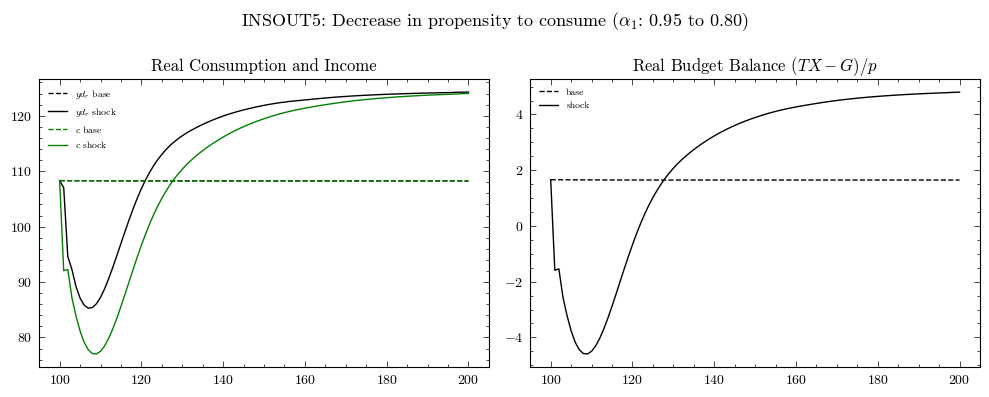

In [71]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 4))

# Real consumption and income
axs[0].plot(output.loc[sl].index, output.loc[sl, 'RealRegularDisposableIncome'], 'k--', label='$yd_r$ base')
axs[0].plot(out5.loc[sl].index, out5.loc[sl, 'RealRegularDisposableIncome'], 'k-', label='$yd_r$ shock')
axs[0].plot(output.loc[sl].index, output.loc[sl, 'RealConsumption'], 'g--', label='$c$ base')
axs[0].plot(out5.loc[sl].index, out5.loc[sl, 'RealConsumption'], 'g-', label='$c$ shock')
axs[0].set_title('Real Consumption and Income')
axs[0].legend(frameon=False, fontsize=7)

# Real budget balance
budget_base = (output.loc[sl, 'Taxes'].values - output.loc[sl, 'GovernmentSpending'].values) / output.loc[sl, 'PriceLevel'].values
budget_shock = (out5.loc[sl, 'Taxes'].values - out5.loc[sl, 'GovernmentSpending'].values) / out5.loc[sl, 'PriceLevel'].values
axs[1].plot(output.loc[sl].index, budget_base, 'k--', label='base')
axs[1].plot(out5.loc[sl].index, budget_shock, 'k-', label='shock')
axs[1].set_title('Real Budget Balance $(TX - G)/p$')
axs[1].legend(frameon=False, fontsize=7)

fig.suptitle(r'INSOUT5: Decrease in propensity to consume ($\alpha_1$: 0.95 to 0.80)', fontsize=13)
plt.tight_layout()
plt.show()

### Perturbation 6: Exogenous Increase in Inflation via Wage Target (INSOUT6)

An increase in the real wage target constant from $\Omega_0 = -0.32549$ to $\Omega_0 = -0.2$. Workers push for a higher real wage, triggering a wage-price spiral.

In [72]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc6 = scenarios.get_scenario_index("Scenario.6: Higher real wage target")
model6 = GL06INSOUT(parameters=params, scenarios=scenarios)
model6.simulate(scenario=sc6)
out6 = model6.variables.to_pandas()

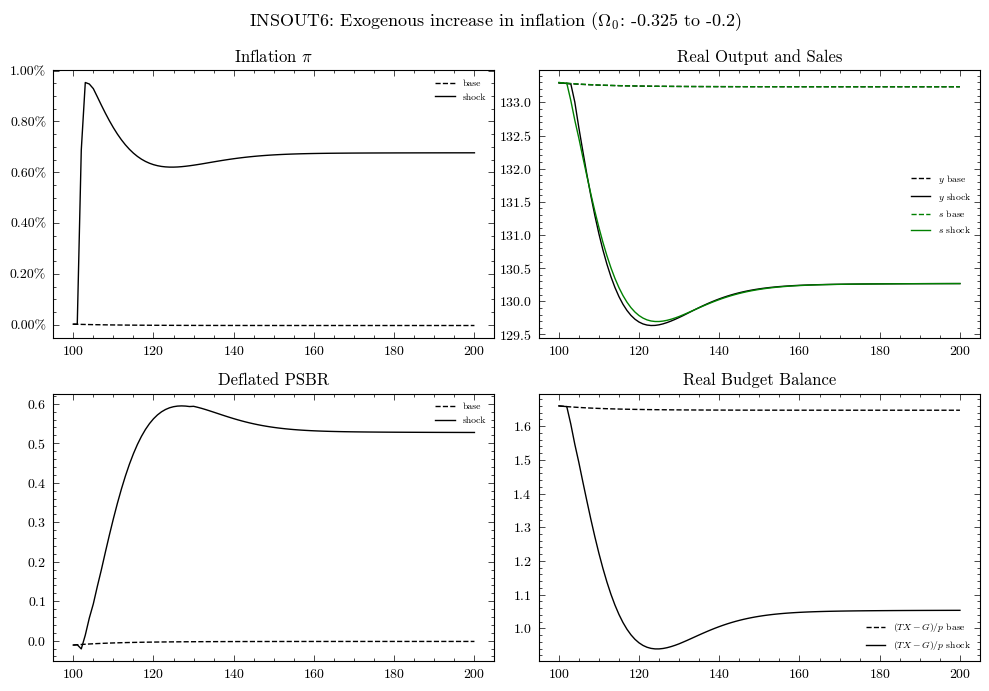

In [73]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 7))

# Inflation
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'InflationRate'], 'k--', label='base')
axs[0, 0].plot(out6.loc[sl].index, out6.loc[sl, 'InflationRate'], 'k-', label='shock')
axs[0, 0].set_title(r'Inflation $\pi$')
axs[0, 0].yaxis.set_major_formatter(PercentFormatter(1))
axs[0, 0].legend(frameon=False, fontsize=7)

# Real output and sales
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'RealOutput'], 'k--', label='$y$ base')
axs[0, 1].plot(out6.loc[sl].index, out6.loc[sl, 'RealOutput'], 'k-', label='$y$ shock')
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'RealSales'], 'g--', label='$s$ base')
axs[0, 1].plot(out6.loc[sl].index, out6.loc[sl, 'RealSales'], 'g-', label='$s$ shock')
axs[0, 1].set_title('Real Output and Sales')
axs[0, 1].legend(frameon=False, fontsize=7)

# Deflated PSBR
p_base = output.loc[sl, 'PriceLevel'].values
p_shock = out6.loc[sl, 'PriceLevel'].values
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'PublicSectorBorrowingRequirement'].values / p_base, 'k--', label='base')
axs[1, 0].plot(out6.loc[sl].index, out6.loc[sl, 'PublicSectorBorrowingRequirement'].values / p_shock, 'k-', label='shock')
axs[1, 0].set_title('Deflated PSBR')
axs[1, 0].legend(frameon=False, fontsize=7)

# Real budget balance
budget_base = (output.loc[sl, 'Taxes'].values - output.loc[sl, 'GovernmentSpending'].values) / p_base
budget_shock = (out6.loc[sl, 'Taxes'].values - out6.loc[sl, 'GovernmentSpending'].values) / p_shock
axs[1, 1].plot(output.loc[sl].index, budget_base, 'k--', label='$(TX-G)/p$ base')
axs[1, 1].plot(out6.loc[sl].index, budget_shock, 'k-', label='$(TX-G)/p$ shock')
axs[1, 1].set_title('Real Budget Balance')
axs[1, 1].legend(frameon=False, fontsize=7)

fig.suptitle(r'INSOUT6: Exogenous increase in inflation ($\Omega_0$: -0.325 to -0.2)', fontsize=13)
plt.tight_layout()
plt.show()

### Perturbation 7: Combined Wage Push and Interest Rate Increase (INSOUT7)

A simultaneous wage push ($\Omega_0$: -0.325 to -0.2) and interest rate increase ($r_b$: 0.023 to 0.03, $r_{bl}$: 0.027 to 0.039). This stagflation experiment shows the interaction between cost-push inflation and monetary contraction.

In [74]:
scenarios = ScenariosGL06INSOUT(parameters=params)
sc7 = scenarios.get_scenario_index("Scenario.7: Wage target + rate rise")
model7 = GL06INSOUT(parameters=params, scenarios=scenarios)
model7.simulate(scenario=sc7)
out7 = model7.variables.to_pandas()

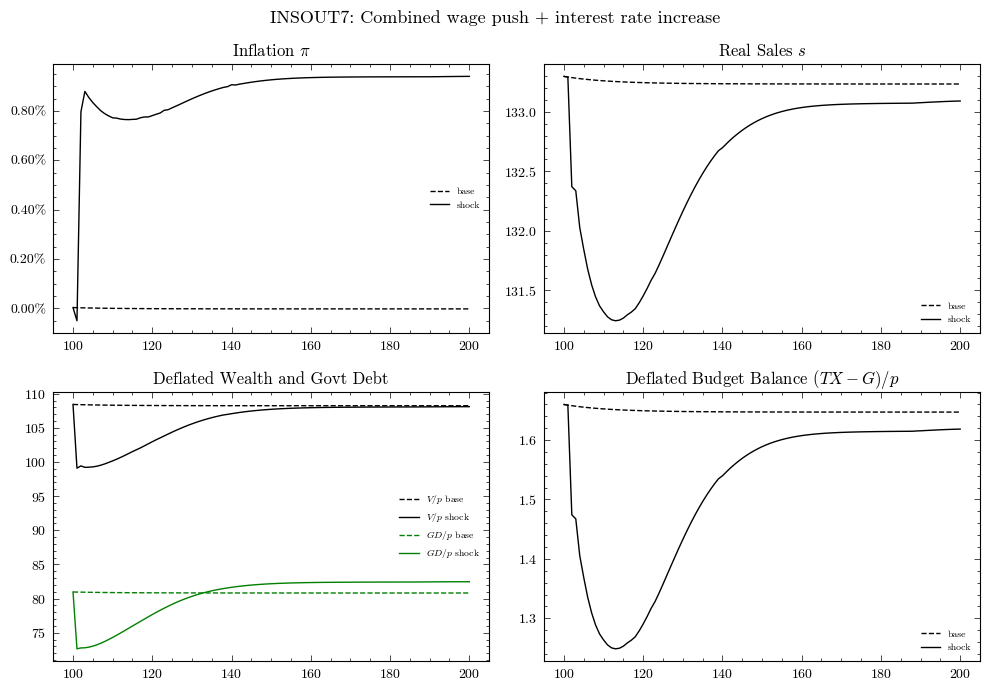

In [75]:
trigger = params["scenario_trigger"]
sl = slice(trigger, None)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 7))

# Inflation
axs[0, 0].plot(output.loc[sl].index, output.loc[sl, 'InflationRate'], 'k--', label='base')
axs[0, 0].plot(out7.loc[sl].index, out7.loc[sl, 'InflationRate'], 'k-', label='shock')
axs[0, 0].set_title(r'Inflation $\pi$')
axs[0, 0].yaxis.set_major_formatter(PercentFormatter(1))
axs[0, 0].legend(frameon=False, fontsize=7)

# Real sales
axs[0, 1].plot(output.loc[sl].index, output.loc[sl, 'RealSales'], 'k--', label='base')
axs[0, 1].plot(out7.loc[sl].index, out7.loc[sl, 'RealSales'], 'k-', label='shock')
axs[0, 1].set_title('Real Sales $s$')
axs[0, 1].legend(frameon=False, fontsize=7)

# Deflated wealth vs government debt
p_base = output.loc[sl, 'PriceLevel'].values
p_shock = out7.loc[sl, 'PriceLevel'].values
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'NominalWealth'].values / p_base, 'k--', label='$V/p$ base')
axs[1, 0].plot(out7.loc[sl].index, out7.loc[sl, 'NominalWealth'].values / p_shock, 'k-', label='$V/p$ shock')
axs[1, 0].plot(output.loc[sl].index, output.loc[sl, 'GovernmentDebt'].values / p_base, 'g--', label='$GD/p$ base')
axs[1, 0].plot(out7.loc[sl].index, out7.loc[sl, 'GovernmentDebt'].values / p_shock, 'g-', label='$GD/p$ shock')
axs[1, 0].set_title('Deflated Wealth and Govt Debt')
axs[1, 0].legend(frameon=False, fontsize=7)

# Deflated budget balance
budget_base = (output.loc[sl, 'Taxes'].values - output.loc[sl, 'GovernmentSpending'].values) / p_base
budget_shock = (out7.loc[sl, 'Taxes'].values - out7.loc[sl, 'GovernmentSpending'].values) / p_shock
axs[1, 1].plot(output.loc[sl].index, budget_base, 'k--', label='base')
axs[1, 1].plot(out7.loc[sl].index, budget_shock, 'k-', label='shock')
axs[1, 1].set_title('Deflated Budget Balance $(TX-G)/p$')
axs[1, 1].legend(frameon=False, fontsize=7)

fig.suptitle('INSOUT7: Combined wage push + interest rate increase', fontsize=13)
plt.tight_layout()
plt.show()